<a href="https://colab.research.google.com/github/nushuhu51-ux/TENSORFLOW-FULL-COURSE-FOR-DEEP-LEARNING/blob/main/01_neural_network_regression_with_tensorflow_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to Regression with Neural Networks in TensorFlowiy.

There many definitions for a regression problems in our case, we're going to simplify:predicting a numerical variable based on some other combination of variable's, even shorter..predicting a number.

In [18]:
# import TensorFlow
import tensorflow as tf
print(tf.__version__)

2.20.0


### Creating data to view and fit

(<matplotlib.collections.PathCollection at 0x7dc0d3533890>,)

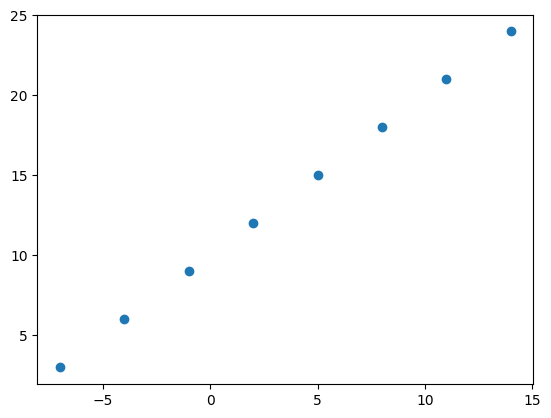

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# create features
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0, ])

# create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# visualize
plt.scatter(x, y),

In [20]:
y == x+10

array([ True,  True,  True,  True,  True,  True,  True,  True])

### Input and output shapes

In [21]:
# create a demo tensor for our housing price prediction problems
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])

house_info, house_price


(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [22]:
input_shape = x[0].shape
output_shape = y[0].shape

input_shape, output_shape

((), ())

In [23]:
x[0].ndim

0

In [24]:
x[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [25]:
# Turn our Numpy array into tensors
x = tf.cast(tf.constant(x), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)
x, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [26]:
input_shape = x[0].shape
output_shape = y[0].shape

input_shape, output_shape

(TensorShape([]), TensorShape([]))

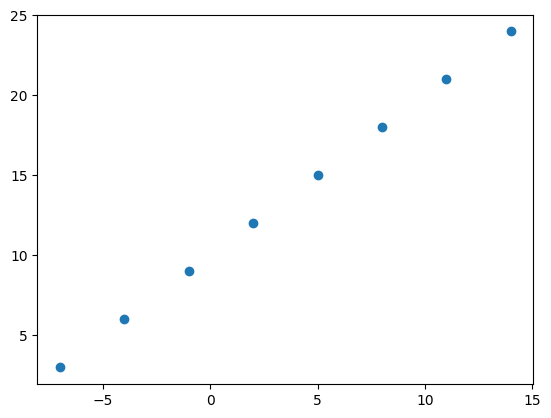

In [27]:
plt.scatter(x, y)

### steps in modelling with TensorFlow

1. Creating a model - define the input and output layer, as well as the hidden layers of a deep learing model.
2. Compiling a model - define the loss function (in other words, the function which tells our model how wrong it is) and the optimizer(tells our model how to improve the patterns its learning) and evaluation metrics(what we can use to interpret the performance of our model).
3. Fitting a model-letting the model try to find patterns between x & y (features and labels)

In [28]:
x = tf.reshape(x, (-1, 1))

In [29]:
# 1. Create a model (specified to your problem)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# 3. Fit the model
model.fit(x, y, epochs=5)

# 4. Evaluate the model
model.evaluate(x, y)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - loss: 20.8485 - mae: 20.8485
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 20.4809 - mae: 20.4809
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 20.1996 - mae: 20.1996
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 19.9184 - mae: 19.9184
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 19.6371 - mae: 19.6371
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 19.3559 - mae: 19.3559


[19.355873107910156, 19.355873107910156]

In [30]:
# check out x and y
x, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [31]:
# try and make a prediction using our model
y_pred = model.predict(tf.constant([[17.0]]))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


array([[-21.44045]], dtype=float32)

In [32]:
y_pred+11

array([[-10.440451]], dtype=float32)

### Improving our model

we can improve our model, by altering the steps we took to create a model.

1. **Creating a model** - define the input and output layer, as well as the hidden layers of a deep learing model.
2. **Compiling a model** - here we night fit change the optimization function or perhaps the **learning rate** of the optimization function
3. **Fitting a model** - here we might fit a model for more (give the model more examples to learn from)

In [37]:
# let's rebuild our model

# 1. create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# 2. compile the model
model.compile(loss=tf.keras.losses.mae, # mae is short for mean absolute error
              optimizer=tf.keras.optimizers.SGD(), # sgd is short for stochasitc dradiant descent
              metrics=["mae"])
# 3. fit the model
model.fit(x, y, epochs=100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step - loss: 11.1522 - mae: 11.1522
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 11.0197 - mae: 11.0197
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 10.8872 - mae: 10.8872
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 10.7547 - mae: 10.7547
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 10.6222 - mae: 10.6222
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 10.4897 - mae: 10.4897
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 10.3572 - mae: 10.3572
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 10.2247 - mae: 10.2247
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.0922 - mae: 10.0922
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 9.9597 - mae: 9.9597
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 9.8272 - mae: 9.8272
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 9.6947 - mae: 9.6947
Epoch 13/100
1/1 ━━━━━━━━━━━━━